In [1]:
# Requires RDKit installed
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import MolsToImage
from rdkit.Chem import Draw

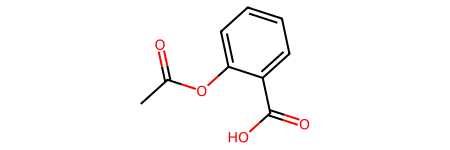

In [2]:
smiles = "CC(=O)Oc1ccccc1C(=O)O"  # aspirin example
mol = Chem.MolFromSmiles(smiles)
mol

In [3]:
Draw.MolToFile(mol, "aspirin.svg", size=(400, 300))

In [4]:
info = {}
fp = AllChem.GetMorganFingerprint(mol, radius=2, bitInfo=info)
fp

[00:12:17] DEPRECATION WARNING: please use MorganGenerator


In [5]:
for bit_id, occurrences in list(info.items())[:6]:
    for (atom_id, rad) in occurrences:
        # 1️⃣ Obtener enlaces (bonds) en el entorno del átomo
        bond_ids = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_id)

        # 2️⃣ Convertir esos enlaces en átomos asociados
        atom_ids = set()
        for b in bond_ids:
            bond = mol.GetBondWithIdx(b)
            atom_ids.add(bond.GetBeginAtomIdx())
            atom_ids.add(bond.GetEndAtomIdx())

        # Asegurar que incluimos el átomo central
        atom_ids.add(atom_id)

        # 3️⃣ Crear el fragmento SMILES
        env_smiles = Chem.MolFragmentToSmiles(mol, atomsToUse=list(atom_ids), canonical=True)
        print(f"bit {bit_id}: atom {atom_id}, radius {rad} -> fragment SMILES: {env_smiles}")

bit 98513984: atom 6, radius 1 -> fragment SMILES: ccc
bit 98513984: atom 7, radius 1 -> fragment SMILES: ccc
bit 132611095: atom 10, radius 2 -> fragment SMILES: cc(C(=O)O)c
bit 509662800: atom 9, radius 2 -> fragment SMILES: ccc(C(=O)O)c(O)c
bit 673156540: atom 3, radius 2 -> fragment SMILES: cc(OC(C)=O)c
bit 864662311: atom 12, radius 0 -> fragment SMILES: O
bit 864674487: atom 3, radius 0 -> fragment SMILES: O


In [6]:
# Save molecule image (SVG/PNG) for use in Figma
img = MolsToImage([mol], subImgSize=(300,300))
img.save("aspirin_mol.png")

In [7]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect

# Ejemplo: aspirina
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# Calcula bitInfo para ver qué átomos y radios activan cada bit
bitInfo = {}
fp = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bitInfo)

# Tomemos los primeros 4 bits activados
active_bits = list(bitInfo.keys())[:4]

imgs = []
for bit in active_bits:
    for atom_id, radius in bitInfo[bit]:
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_id)
        submol = Chem.PathToSubmol(mol, env)
        img = Draw.MolToImage(submol, size=(150, 150), legend=f"bit {bit}")
        imgs.append(img)


[00:12:17] DEPRECATION WARNING: please use MorganGenerator


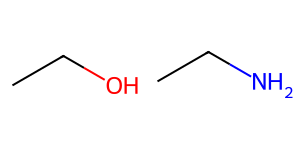

In [8]:
from PIL import Image

# Combina los fragmentos en una sola imagen (2x2 grid)
combined = Draw.MolsToGridImage([Chem.MolFromSmiles("CCO"), Chem.MolFromSmiles("CCN")],
                                molsPerRow=2, subImgSize=(150,150))

combined

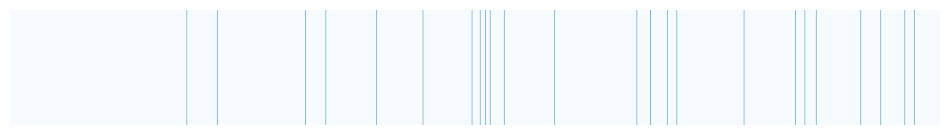

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# fp es un ExplicitBitVect de RDKit
arr = np.zeros((2048,), dtype=int)
Chem.DataStructs.ConvertToNumpyArray(fp, arr)

plt.figure(figsize=(12, 1.5))
plt.imshow(arr[np.newaxis, :], cmap="Blues", aspect="auto")
plt.axis("off")
plt.savefig("ecfp_bitvector.svg", bbox_inches="tight", dpi=300)


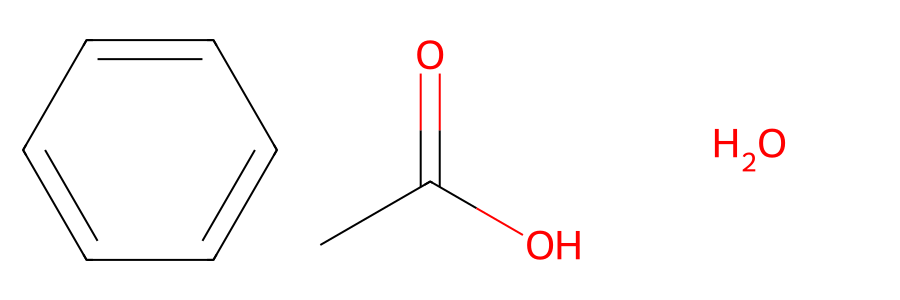

In [10]:
frags = ["c1ccccc1", "CC(=O)O", "O"]
mols = [Chem.MolFromSmiles(f) for f in frags]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,300))
img

In [11]:
from rdkit.Chem.Draw import MolToFile

i = 0
for mol in mols:
    MolToFile(mol, f'mol{i}.svg')
    i += 1